In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [3]:
cols = ['engine_id','cycle'] + [f'setting_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]

train_df = pd.read_csv('../data/train_FD001.txt', sep='\s+', header=None,names=cols,engine='python')
train_df.drop(columns=['sensor_22','sensor_23'],inplace=True, errors='ignore')

#Add RUL column
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id','max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

print(train_df.shape)
train_df.head()

(20631, 27)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [4]:
print("shape:", train_df.shape)
print("\nMissing Vslues:\n", train_df.isnull().sum().sum())
print("\nUnique Engines:", train_df['engine_id'].nunique())
print("\nDescribe:\n", train_df.describe().round(2))

shape: (20631, 27)

Missing Vslues:
 0

Unique Engines: 100

Describe:
        engine_id     cycle  setting_1  setting_2  setting_3  sensor_1  \
count   20631.00  20631.00   20631.00    20631.0    20631.0  20631.00   
mean       51.51    108.81      -0.00        0.0      100.0    518.67   
std        29.23     68.88       0.00        0.0        0.0      0.00   
min         1.00      1.00      -0.01       -0.0      100.0    518.67   
25%        26.00     52.00      -0.00       -0.0      100.0    518.67   
50%        52.00    104.00       0.00        0.0      100.0    518.67   
75%        77.00    156.00       0.00        0.0      100.0    518.67   
max       100.00    362.00       0.01        0.0      100.0    518.67   

       sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  \
count  20631.00  20631.00  20631.00  20631.00  ...   20631.00   20631.00   
mean     642.68   1590.52   1408.93     14.62  ...    2388.10    8143.75   
std        0.50      6.13      9.00      0

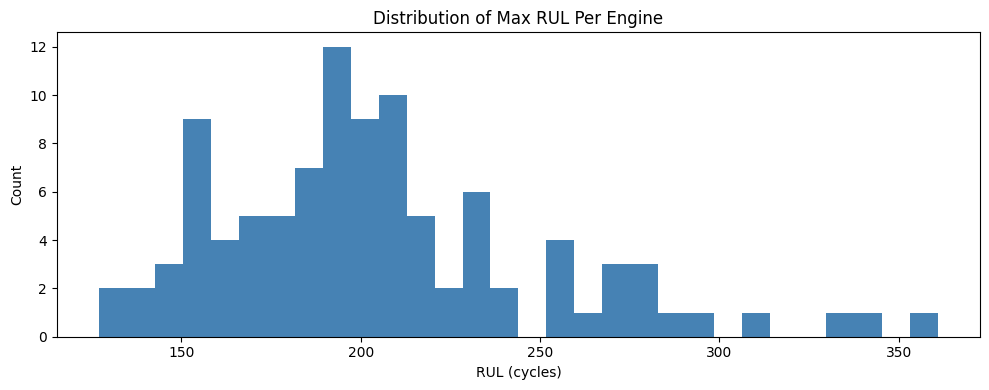

In [5]:
plt.figure(figsize=(10,4))
plt.hist(train_df.groupby('engine_id')['RUL'].max(),bins=30, color='steelblue')
plt.title('Distribution of Max RUL Per Engine')
plt.xlabel('RUL (cycles)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../notebooks/rul_distribution.png')
plt.show()

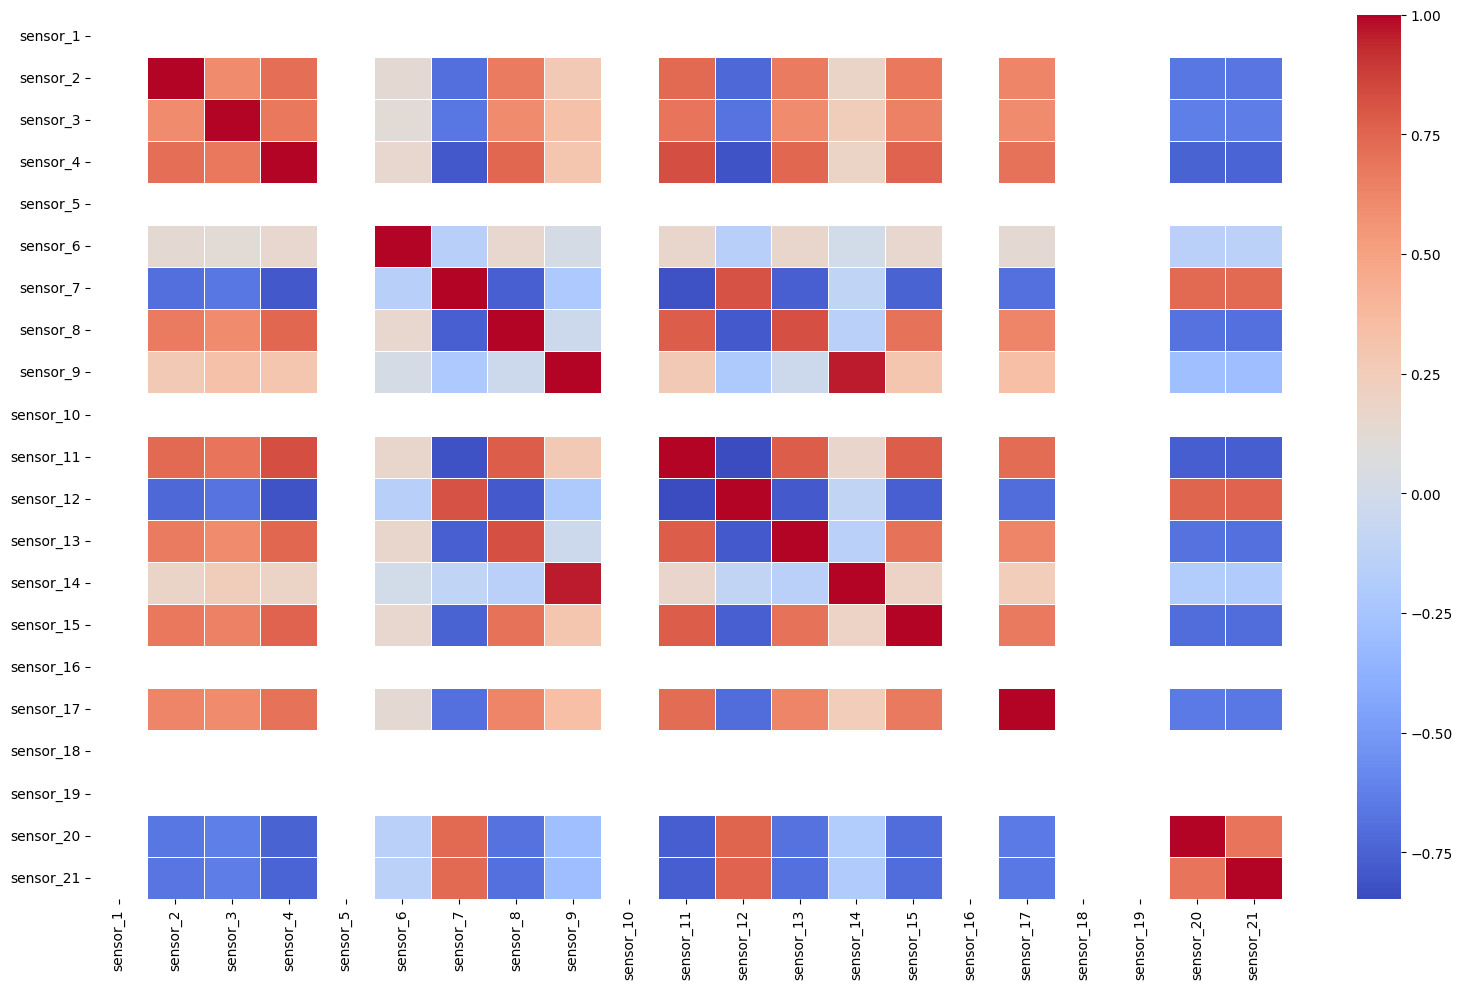

In [6]:
sensors_cols = [f'sensor_{i}' for i in range(1,22)]
plt.figure(figsize=(16,10))
sns.heatmap(train_df[sensors_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png')
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_cols = [col for col in sensor_cols if col in train_df.columns]
useful_sensors = [col for col in sensor_cols 
                  if train_df[col].std() > 0.001]

engine1_data = train_df[train_df['engine_id'] == 1].copy()

results = []
for sensor in useful_sensors:
    values = engine1_data[sensor].dropna().values

    if len(values) < 10:
        continue
    if len(set(values)) == 1:
        continue

    try:
        adf_stat, adf_p, _, _, _, _ = adfuller(values)
    except:
        continue

    try:
        kpss_stat, kpss_p, _, _ = kpss(values, regression='c', nlags='auto')
    except:
        kpss_p = None

    results.append({
        'Sensor'      : sensor,
        'ADF p-value' : round(adf_p, 4),
        'ADF Result'  : "Stationary" if adf_p < 0.05 else "Non-stationary",
        'KPSS p-value': round(kpss_p, 4) if kpss_p else 'N/A',
        'KPSS Result' : "Stationary" if (kpss_p and kpss_p > 0.05) else "Non-stationary"
    })

import pandas as pd
results_df = pd.DataFrame(results)
print("\n📊 Stationarity Test Results:\n")
print(results_df.to_string(index=False))


📊 Stationarity Test Results:

   Sensor  ADF p-value     ADF Result  KPSS p-value    KPSS Result
 sensor_2       0.9816 Non-stationary          0.01 Non-stationary
 sensor_3       0.9854 Non-stationary          0.01 Non-stationary
 sensor_4       0.9903 Non-stationary          0.01 Non-stationary
 sensor_7       0.9984 Non-stationary          0.01 Non-stationary
 sensor_8       1.0000 Non-stationary          0.01 Non-stationary
 sensor_9       0.9811 Non-stationary          0.01 Non-stationary
sensor_11       0.9990 Non-stationary          0.01 Non-stationary
sensor_12       0.9932 Non-stationary          0.01 Non-stationary
sensor_13       0.9990 Non-stationary          0.01 Non-stationary
sensor_14       1.0000 Non-stationary          0.01 Non-stationary
sensor_15       0.9985 Non-stationary          0.01 Non-stationary
sensor_17       0.9203 Non-stationary          0.01 Non-stationary
sensor_20       0.9975 Non-stationary          0.01 Non-stationary
sensor_21       0.9986 Non-stat

✅ Running FFT on: sensor_2


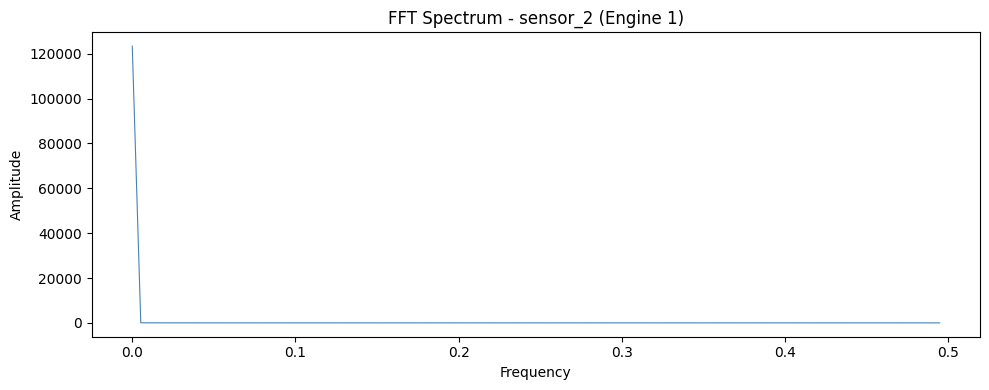

In [ ]:
from numpy.fft import fft, fftfreq

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
useful_sensors = [col for col in sensor_cols 
                  if col in train_df.columns 
                  and train_df[col].std() > 0.001]

engine1_data = train_df[train_df['engine_id'] == 1].copy()

# Auto pick valid sensor
chosen_sensor = None
for sensor in useful_sensors:
    vals = engine1_data[sensor].dropna().values
    if len(vals) > 0 and vals.max() != vals.min():
        chosen_sensor = sensor
        break

print(f"Running FFT on: {chosen_sensor}")
signal = engine1_data[chosen_sensor].dropna().values

n         = len(signal)
fft_vals  = np.abs(fft(signal))
freqs     = fftfreq(n)

plt.figure(figsize=(10, 4))
plt.plot(freqs[:n//2], fft_vals[:n//2], color='steelblue', linewidth=0.8)
plt.title(f'FFT Spectrum - {chosen_sensor} (Engine 1)')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.savefig('../notebooks/fft_spectrum.png')
plt.show()

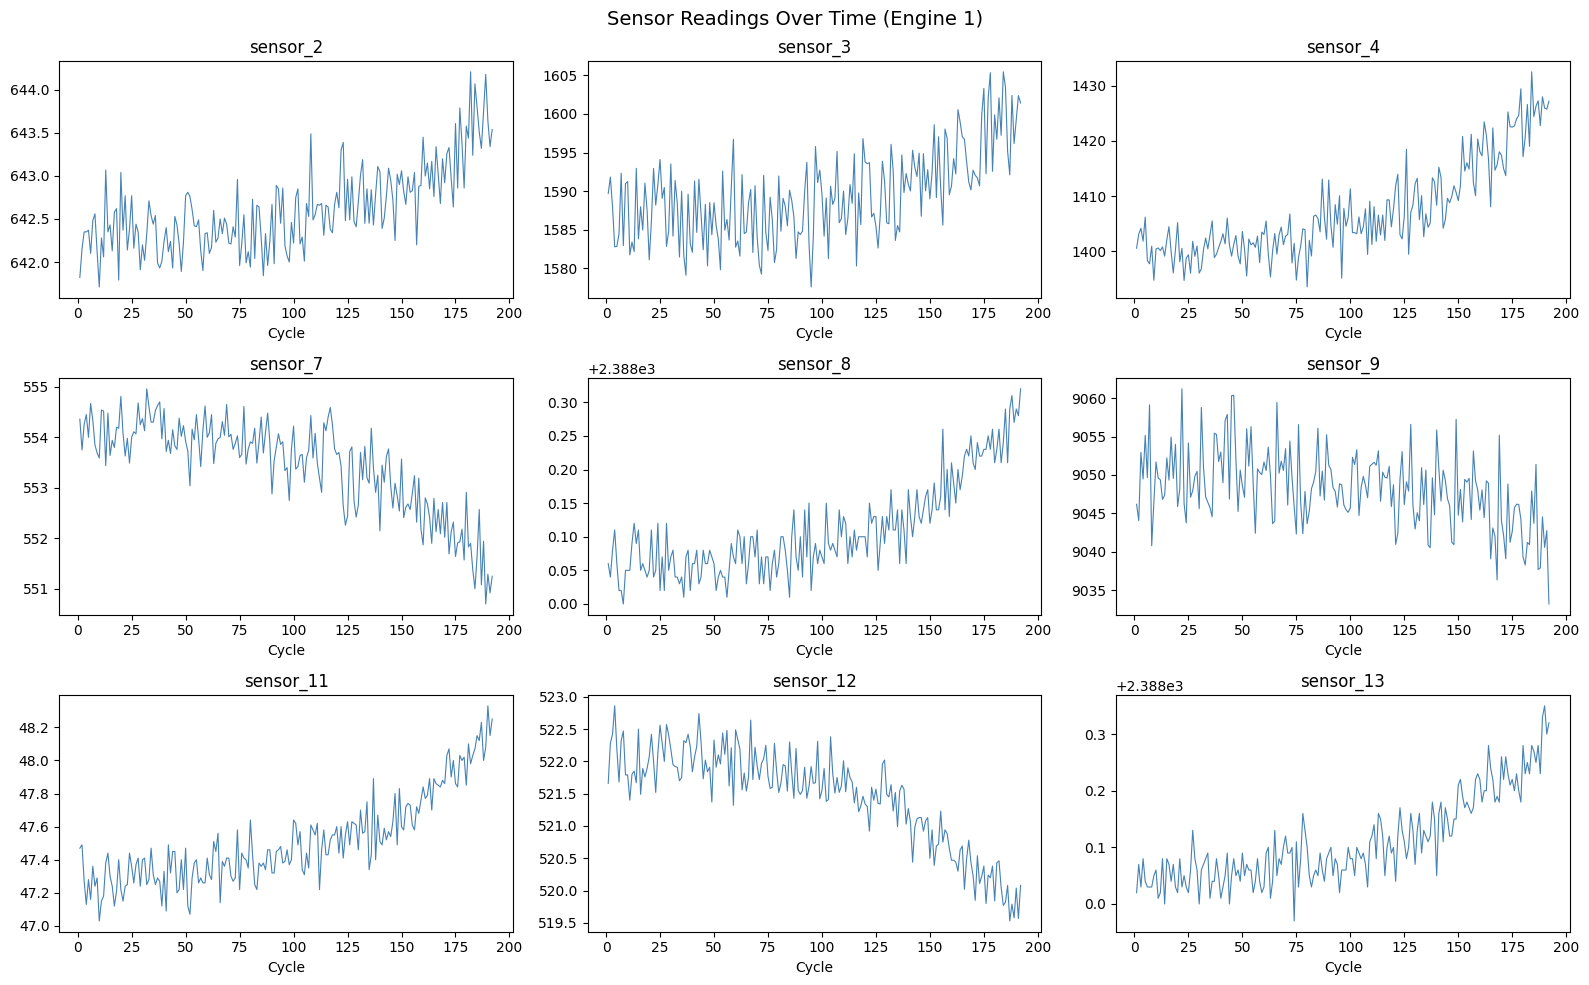

In [11]:
fig, axes = plt.subplots(3,3, figsize=(16,10))
axes = axes.flatten()

for i, sensor in enumerate(['sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9','sensor_11','sensor_12','sensor_13']):
    engine1 = train_df[train_df['engine_id'] == 1]
    axes[i].plot(engine1['cycle'],engine1[sensor], color='steelblue',linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.suptitle('Sensor Readings Over Time (Engine 1)', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/sensor_trends.png')
plt.show()